In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.8 MB/s eta 0:00:0000:01


In [3]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [8]:

model = YOLO('yolov8n.pt')
model.train(data='construction-ppe.yaml', epochs=20, imgsz=640, batch=16, patience=5, project="runs/detect", name="hardhat_training", device="cuda", exist_ok=True)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=construction-ppe.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=hardhat_training, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=5, perspective=0.0

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78f7afed5ee0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.

In [10]:
best = YOLO("runs/detect/runs/detect/hardhat_training/weights/best.pt")

In [12]:
best.val()

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1849.0±760.0 MB/s, size: 132.2 KB)
val: Scanning /content/datasets/construction-ppe/labels/val.cache... 143 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 143/143 42.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.2it/s 4.0s0.2ss
                   all        143       1172      0.785      0.502      0.566      0.281
                helmet        107        201      0.848      0.841      0.856      0.464
                gloves         68        136      0.838      0.722       0.81      0.385
                  vest        109        171      0.832      0.795      0.857      0.516
                 boots         64        151       0.72      0.748      0.791      0.464
               goggles         44         47      0.889      0.723      0.778      0.354
                  non

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78f8942848c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.

In [14]:
import cv2
import matplotlib.pyplot as plt
import pathlib
import os

In [15]:
pred = best.predict(
    source="https://img.freepik.com/free-photo/civil-engineer-construction-worker-architects-wearing-hardhats-safety-vests-are-working-together-construction-site-building-home-cooperation-teamwork-concept_640221-172.jpg",
    conf=0.3,
    save=True
)


image 1/1 /content/civil-engineer-construction-worker-architects-wearing-hardhats-safety-vests-are-working-together-construction-site-building-home-cooperation-teamwork-concept_640221-172.jpg: 448x640 3 helmets, 3 vests, 1 none, 3 Persons, 46.1ms
Speed: 3.6ms preprocess, 46.1ms inference, 1.9ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict


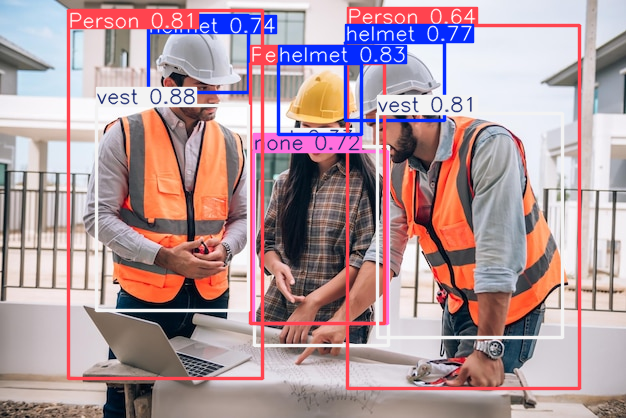

In [17]:
pred[0].show()

In [21]:
best.export(format="onnx")

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from 'runs/detect/runs/detect/hardhat_training/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 15, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 368ms
Prepared 4 packages in 3.83s
Installed 4 packages in 338ms
 + colorama==0.4.6
 + onnx==1.20.1
 + onnxruntime-gpu==1.24.2
 + onnxslim==0.1.86

requirements: AutoUpdate success ✅ 5.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 22...


/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/utils.py:1447: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  warnings.warn(


ONNX: slimming with onnxslim 0.1.86...
ONNX: export success ✅ 7.7s, saved as 'runs/detect/runs/detect/hardhat_training/weights/best.onnx' (11.7 MB)

Export complete (8.4s)
Results saved to /content/runs/detect/runs/detect/hardhat_training/weights
Predict:         yolo predict task=detect model=runs/detect/runs/detect/hardhat_training/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=runs/detect/runs/detect/hardhat_training/weights/best.onnx imgsz=640 data=/usr/local/lib/python3.12/dist-packages/ultralytics/cfg/datasets/construction-ppe.yaml  
Visualize:       https://netron.app


'runs/detect/runs/detect/hardhat_training/weights/best.onnx'